## Faithfulness metrics
`Does the explanation reflect what the model actually uses?` 

These are the most important category for interpretability-audit angle — they test whether the highlighted regions causally matter to the prediction, not just whether they look plausible.
- **Deletion / Insertion** [(Petsiuk et al., RISE paper)](http://bmvc2018.org/contents/papers/1064.pdf): progressively remove (deletion) or add (insertion) pixels ranked by attribution importance, and track how prediction confidence drops/rises. Plot confidence vs. fraction of pixels removed/inserted, then compute the AUC of that curve.
    - Deletion: steep, fast drop = good explanation (the model really was using those pixels)
    - Insertion: fast rise = good explanation
    - This is class-agnostic and works for any attribution method producing per-pixel importance, so it directly compares Grad-CAM vs. Guided Grad-CAM vs. IG on equal footing.
- **Pixel/Region flipping** (a.k.a. perturbation curves): Similar idea to deletion but sometimes done in patches rather than pixels, replacing with a baseline (mean color, blur, or noise) rather than zero — this avoids introducing unnatural "black hole" artifacts that a CNN might react to for the wrong reasons (an artifact of naive deletion that's a known confound; blurring is often preferred for medical images).

In [20]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt

from utils.tools import *
from utils.training import *

## Test set

In [6]:
root = '/gpfs01/berens/data/data/medical_imaging/Dermoscopy/ISIC_2018/Task3'
img_test_dir = os.path.join(root, 'Test_Input')

df_test = pd.read_csv(os.path.join('save/test_inference.csv'))
df_test.head(3)

df = df_test[df_test.label == df_test.pred].reset_index(drop=True)

print(df_test.shape, df.shape)

(1512, 10) (1264, 10)


## Load model

In [13]:
xai = False
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') 

model = build_model(num_classes=7, backbone='resnet50')
model.load_state_dict(torch.load('save/best_model.pth', map_location=device))

<All keys matched successfully>

## Deletion / Insertion
### Deletion
- Start with the original image.
- Progressively remove (replace with a baseline) the pixels the explanation says are most important, in order.
- Track the model's confidence in the predicted class after each removal step.
- A good explanation causes **a fast, steep drop** in confidence — because we're removing genuinely important pixels first.
- The metric is the AUC of the confidence-vs-fraction-removed curve — **lower AUC = better explanation**.

### Insertion
- Start from a fully blurred/baseline image (no information), and progressively add back pixels in order of importance.
- A good explanation causes a fast rise in confidence. **Higher AUC = better explanation**.

`Choose a baseline (what "removed" pixels become)` > Using pure black/zero pixels is common but can introduce a strong edge artifact that CNNs react to unnaturally. For medical images, a blurred version of the image is the more defensible baseline (this is what the original RISE paper recommends too).

In [17]:
def get_blurred_baseline(image_tensor, kernel_size=51, sigma=41):
    """
    Step 2 — Choose a baseline (what "removed" pixels become)
    
    image_tensor: [C, H, W], on CPU, unnormalized in [0,1] (or normalized - blur works either way)
    Returns a heavily blurred version to use as the 'no information' baseline.
    """
    img_np = image_tensor.permute(1, 2, 0).numpy()
    blurred = cv2.GaussianBlur(img_np, (kernel_size, kernel_size), sigma)
    return torch.tensor(blurred).permute(2, 0, 1).float()

In [46]:
def deletion_insertion(model, image_tensor, attribution_map, target_class, device, n_steps=50, mode='deletion', baseline=None):
    """
    Step 3 — Core Deletion/Insertion function
    
    image_tensor: [C, H, W] normalized tensor (single image, not batched)
    attribution_map: [H, W] numpy array, same spatial size as image_tensor
    target_class: int, class index to track confidence for
    mode: 'deletion' or 'insertion'
    baseline: [C, H, W] tensor to substitute pixels with (blurred image recommended)
    """
    model.eval()
    C, H, W = image_tensor.shape

    if baseline is None:
        baseline = get_blurred_baseline(image_tensor)

    flat_attr = attribution_map.flatten()
    order = np.argsort(-flat_attr)  # most important pixel indices first
    total_pixels = len(order)
    step_size = max(1, total_pixels // n_steps)

    # 'revealed' tracks which pixels currently show the ORIGINAL image
    # deletion: starts all True (full original), flips to False (baseline) as we go
    # insertion: starts all False (full baseline), flips to True (original) as we go
    revealed = np.ones(total_pixels, dtype=bool) if mode == 'deletion' else np.zeros(total_pixels, dtype=bool)

    scores = []
    with torch.no_grad():
        for step in range(0, n_steps + 1):
            if step > 0:
                start = (step - 1) * step_size
                end = step * step_size if step < n_steps else total_pixels
                idx = order[start:end]
                if mode == 'deletion':
                    revealed[idx] = False   # remove these important pixels
                else:
                    revealed[idx] = True    # reveal these important pixels

            mask = torch.tensor(revealed.reshape(H, W), dtype=torch.bool).unsqueeze(0).expand(C, H, W)
            working_image = torch.where(mask, image_tensor, baseline)

            input_batch = working_image.unsqueeze(0).to(device)
            prob = F.softmax(model(input_batch), dim=1)[0, target_class].item()
            scores.append(prob)

    return np.array(scores)

In [52]:
def compute_auc(scores):
    '''
        Step 4 — Compute AUC from the score curve
    '''
    x = np.linspace(0, 1, len(scores))
    return np.trapezoid(scores, x)

In [43]:
def evaluate_deletion_insertion(model, image_tensor, attribution_map, target_class, device, n_steps=50):
    '''
        Step 5 — Put it together: run for one image + one attribution method
    '''
    baseline = get_blurred_baseline(image_tensor.cpu())

    del_scores = deletion_insertion(model, image_tensor.cpu(), attribution_map, target_class,
                                     device, n_steps=n_steps, mode='deletion', baseline=baseline)
    ins_scores = deletion_insertion(model, image_tensor.cpu(), attribution_map, target_class,
                                     device, n_steps=n_steps, mode='insertion', baseline=baseline)

    del_auc = compute_auc(del_scores)
    ins_auc = compute_auc(ins_scores)

    return del_auc, ins_auc, del_scores, ins_scores

In [61]:
def plot_deletion_insertion(del_scores, ins_scores, del_auc, ins_auc, title=""):
    '''
        Step 6 — Visualize the curves (sanity check before trusting the numbers)
    '''
    x = np.linspace(0, 1, len(del_scores))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(x, del_scores)
    axes[0].fill_between(x, del_scores, alpha=0.2)
    axes[0].set_title(f"Deletion (AUC={del_auc:.4f}, lower=better)")
    axes[0].set_xlabel("Fraction removed")
    axes[0].set_ylabel("Class probability")

    axes[1].plot(x, ins_scores, color='green')
    axes[1].fill_between(x, ins_scores, alpha=0.2, color='green')
    axes[1].set_title(f"Insertion (AUC={ins_auc:.4f}, higher=better)")
    axes[1].set_xlabel("Fraction inserted")
    axes[1].set_ylabel("Class probability")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
plt.imshow

In [40]:
df_tmp = df.sample()
fname, label, pred = df_tmp.image.tolist()[0], df_tmp.label.tolist()[0], df_tmp.pred.tolist()[0], 

ts_img, np_img = get_ts_img(root, fname, img_test_dir, batch=True)

print(ts_img.shape)

torch.Size([1, 3, 600, 450])


In [42]:
gc, guided_gc, y = compute_attributions(model, ts_img, device)
attrib_map = gc.squeeze(0)
image_tensor = ts_img.squeeze(0)

In [53]:
attrib_map = attrib_map.detach().cpu()
del_auc, ins_auc, del_scores, ins_scores = evaluate_deletion_insertion(model, image_tensor, attrib_map, y, device, n_steps=50)

In [57]:
len(del_scores)

51

## Step 7 — Run it end-to-end on one example, comparing Grad-CAM vs Guided Grad-CAM

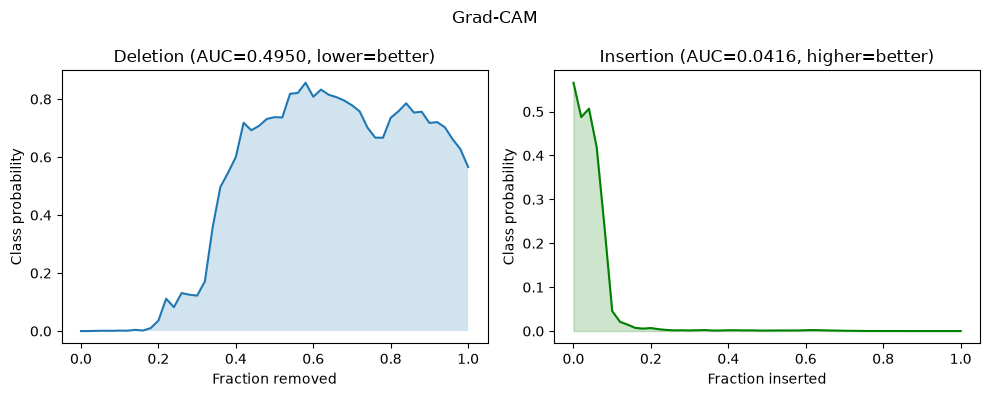

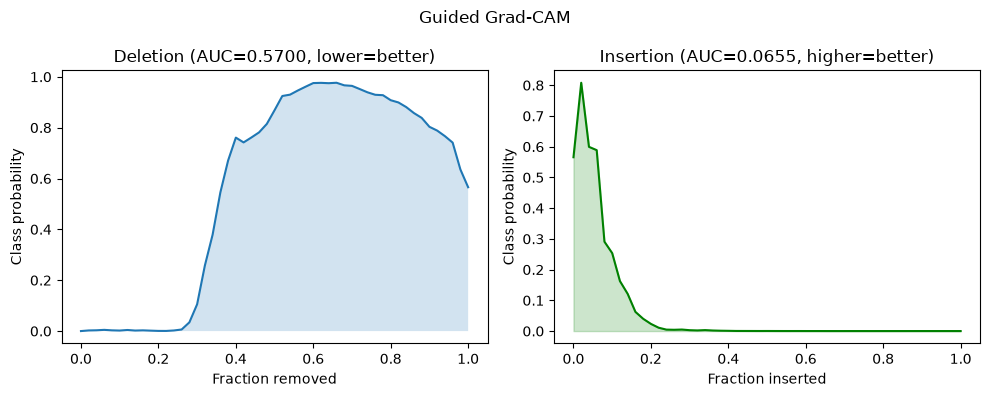

Grad-CAM         | Deletion AUC: 0.4950 | Insertion AUC: 0.0416
Guided Grad-CAM  | Deletion AUC: 0.5700 | Insertion AUC: 0.0655


In [62]:
# get one sample
df_tmp = df.sample()
fname, label, pred = df_tmp.image.tolist()[0], df_tmp.label.tolist()[0], df_tmp.pred.tolist()[0]
ts_img, np_img = get_ts_img(root, fname, img_test_dir, batch=False)                                # normalized [C,H,W]

# get attributions (from your earlier Captum setup)
input_batch = ts_img.unsqueeze(0)
gradcam_attr, guided_attr, pred_class = compute_attributions(model, input_batch, device)

gradcam_np = gradcam_attr.squeeze().cpu().detach().numpy()          # [H, W]
guided_np = guided_attr.squeeze().cpu().detach().numpy()            # [C, H, W]
guided_np_gray = np.abs(guided_np).sum(axis=0)                      # collapse to [H, W]

# evaluate Grad-CAM
del_auc_gc, ins_auc_gc, del_gc, ins_gc = evaluate_deletion_insertion(model, image_tensor, gradcam_np, pred_class, device, n_steps=50)
plot_deletion_insertion(del_gc, ins_gc, del_auc_gc, ins_auc_gc, title="Grad-CAM")

# evaluate Guided Grad-CAM
del_auc_ggc, ins_auc_ggc, del_ggc, ins_ggc = evaluate_deletion_insertion(model, image_tensor, guided_np_gray, pred_class, device, n_steps=50)
plot_deletion_insertion(del_ggc, ins_ggc, del_auc_ggc, ins_auc_ggc, title="Guided Grad-CAM")

print(f"Grad-CAM         | Deletion AUC: {del_auc_gc:.4f} | Insertion AUC: {ins_auc_gc:.4f}")
print(f"Guided Grad-CAM  | Deletion AUC: {del_auc_ggc:.4f} | Insertion AUC: {ins_auc_ggc:.4f}")

In [64]:
def gradcam_attribution_fn(model, input_batch):
    attr = gradcam.attribute(input_batch, target=None)  # None -> uses argmax internally? check below
    with torch.no_grad():
        pred_class = model(input_batch).argmax(dim=1).item()
    attr = gradcam.attribute(input_batch, target=pred_class)
    attr_upsampled = LayerGradCam.interpolate(attr, input_batch.shape[2:])
    return attr_upsampled.squeeze().cpu().detach().numpy(), pred_class

In [63]:
def run_deletion_insertion_dataset(model, dataset, attribution_fn, device, n_samples=50, n_steps=50, seed=42):
    """
    Step 8 — Scale it up: average over many validation images
    
    attribution_fn: function(model, input_batch) -> (attribution_map [H,W] numpy, pred_class)
                    write one small wrapper per method (Grad-CAM, Guided GC, IG, ...)
    """
    random.seed(seed)
    indices = random.sample(range(len(dataset)), n_samples)

    del_aucs, ins_aucs = [], []
    for idx in tqdm(indices, desc="Evaluating"):
        image, label = dataset[idx]
        image = image.to(device)
        attr_map, pred_class = attribution_fn(model, image.unsqueeze(0))

        del_auc, ins_auc, _, _ = evaluate_deletion_insertion(
            model, image, attr_map, pred_class, device, n_steps=n_steps
        )
        del_aucs.append(del_auc)
        ins_aucs.append(ins_auc)

    return np.array(del_aucs), np.array(ins_aucs)

In [ ]:
del_aucs_gc, ins_aucs_gc = run_deletion_insertion_dataset(model, val_loader.dataset, gradcam_attribution_fn, device, n_samples=100)

print(f"Grad-CAM — Mean Deletion AUC: {del_aucs_gc.mean():.4f} ± {del_aucs_gc.std():.4f}")
print(f"Grad-CAM — Mean Insertion AUC: {ins_aucs_gc.mean():.4f} ± {ins_aucs_gc.std():.4f}")